# MSHA — Maths & Data Science I
## Assignment — Distributions & Exploratory Analysis of Hospital Claims

**AI-use disclosure:** I used Claude (Anthropic) to help develop the code in this notebook, working through the assignment part by part. All outputs were produced by running the code, and the written interpretations are my own.


## Part A — Load & Inspect

**A1. Load the dataset and report its shape.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the claims data directly from the source URL given in the brief
url = ('https://github.com/thousandoaks/Python4DS-I/'
       'raw/main/datasets/HealthcareDataset_PublicRelease.csv')
df = pd.read_csv(url)
print('Shape (rows, columns):', df.shape)

Shape (rows, columns): (52563, 17)


**A2. Column dtypes — which date columns are stored as text?**

In [2]:
# Show every column and its data type
print(df.dtypes)

date_fields = ['StartDate', 'EndDate', 'BirthDate']
stored_as_text = [c for c in date_fields
                  if not pd.api.types.is_datetime64_any_dtype(df[c])]
print()
print('Date columns currently stored as text:', stored_as_text)

# Convert them now - the derived columns in Part B need proper datetimes
for col in date_fields:
    df[col] = pd.to_datetime(df[col])

Id                          int64
MemberName                    str
MemberID                      str
County                        str
MedicalClaim                  str
ClaimItem                   int64
HospitalName                  str
HospitalType                  str
StartDate                     str
EndDate                       str
PrincipalDiagnosisDesc        str
PrincipalDiagnosis            str
RevenueCodeDesc               str
RevenueCode               float64
TypeFlag                      str
BirthDate                     str
TotalExpenses             float64
dtype: object

Date columns currently stored as text: ['StartDate', 'EndDate', 'BirthDate']


*TODO — your own words: note which date columns arrived as text and why they must be converted before any date arithmetic.*

**A3. Missing values per column.**

In [3]:
missing = df.isna().sum()
print(missing)
print()
print('Columns with missing values:', list(missing[missing > 0].index))

Id                        0
MemberName                0
MemberID                  0
County                    0
MedicalClaim              0
ClaimItem                 0
HospitalName              0
HospitalType              0
StartDate                 0
EndDate                   0
PrincipalDiagnosisDesc    0
PrincipalDiagnosis        0
RevenueCodeDesc           2
RevenueCode               0
TypeFlag                  0
BirthDate                 0
TotalExpenses             0
dtype: int64

Columns with missing values: ['RevenueCodeDesc']


**A4. Summary statistics for TotalExpenses.**

In [4]:
df['TotalExpenses'].describe()

count     52563.000000
mean       2735.230373
std        8292.178928
min           0.000000
25%         194.642000
50%         675.262000
75%        2309.265000
max      504533.400000
Name: TotalExpenses, dtype: float64

*TODO — your own words: one sentence comparing the mean to the median and what that implies about skew.*

## Part B — Derive the Analysis Variables

**B1. Age in completed years at 2020-12-31.**

In [5]:
def compute_age(birthdate, ref_date):
    """Return age in completed years at ref_date."""
    return (ref_date.year - birthdate.year
            - ((ref_date.month, ref_date.day) < (birthdate.month, birthdate.day)))

ref_date = pd.Timestamp('2020-12-31')
df['Age'] = df['BirthDate'].apply(lambda b: compute_age(b, ref_date))
df['Age'].describe()

count    52563.000000
mean        72.159123
std         12.230098
min         21.000000
25%         67.000000
50%         73.000000
75%         81.000000
max         99.000000
Name: Age, dtype: float64

**B2. LengthOfStay (days).**

In [6]:
# Length of stay in whole days from the service dates
df['LengthOfStay'] = (df['EndDate'] - df['StartDate']).dt.days
df['LengthOfStay'].describe()

count    52563.000000
mean         3.869109
std          6.008744
min          0.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        129.000000
Name: LengthOfStay, dtype: float64

**B3. Age bands.**

In [7]:
def age_band(age):
    """Map an age in years to its band."""
    if age < 40:
        return '<40'
    elif age < 65:
        return '40–64'
    elif age < 80:
        return '65–79'
    else:
        return '80+'

df['AgeBand'] = df['Age'].apply(age_band)
df['AgeBand'].value_counts()

AgeBand
65–79    27781
80+      14601
40–64     9444
<40        737
Name: count, dtype: int64

**B4. Cost tiers.**

In [8]:
def cost_tier(x):
    """Return 'Low' (<$500), 'Medium' ($500–4,999) or 'High' (>=$5,000)."""
    if x < 500:
        return 'Low'
    elif x < 5000:
        return 'Medium'
    else:
        return 'High'

df['CostTier'] = df['TotalExpenses'].apply(cost_tier)
df['CostTier'].value_counts()

CostTier
Low       22981
Medium    22948
High       6634
Name: count, dtype: int64

## Part C — Continuous Distributions

**C1. Histogram of TotalExpenses with mean, median, std and skewness.**

Mean:        2735.23
Median:       675.26
Std dev:     8292.18
Skewness:      16.05


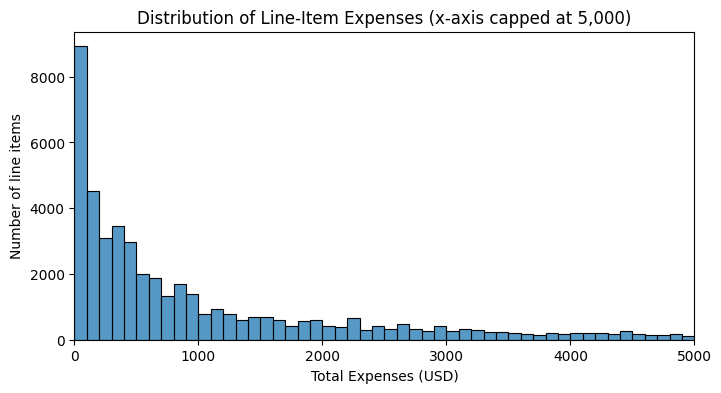

In [9]:
te = df['TotalExpenses']
print(f'Mean:     {te.mean():>10.2f}')
print(f'Median:   {te.median():>10.2f}')
print(f'Std dev:  {te.std():>10.2f}')
print(f'Skewness: {te.skew():>10.2f}')

# Cap the x-axis so the shape is visible despite the extreme right tail
plt.figure(figsize=(8, 4))
sns.histplot(x=te, bins=50, binrange=(0, 5000))
plt.xlim(0, 5000)
plt.title('Distribution of Line-Item Expenses (x-axis capped at 5,000)')
plt.xlabel('Total Expenses (USD)')
plt.ylabel('Number of line items')
plt.show()

*TODO — your own words: 1–2 sentences explaining why the mean sits so far above the median (what the long right tail does to the mean but not the median).*

**C2. Log transform.** `TotalExpenses` contains a small number of zero-value line items, and log(0) is undefined — so we use `log1p` (log of 1 + x), which maps 0 to 0 and keeps every row rather than dropping them.

Zero-value line items: 16
Skewness before transform: 16.05
Skewness after log1p:      -0.43


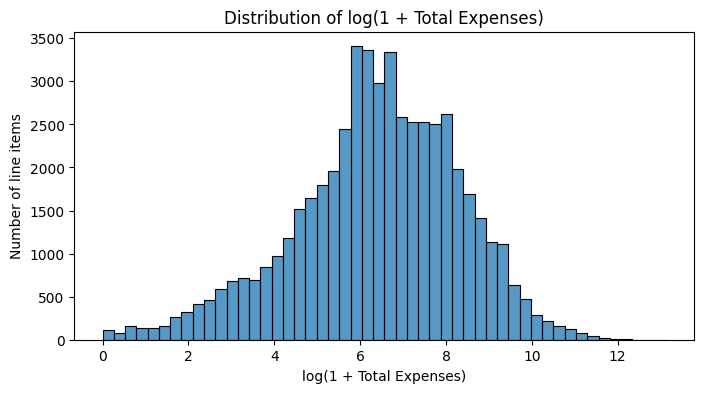

In [10]:
# How many zeros need handling?
print('Zero-value line items:', (te == 0).sum())

# log1p handles zeros: log1p(0) = 0, so no rows are lost
df['LogExpenses'] = np.log1p(te)

print(f'Skewness before transform: {te.skew():.2f}')
print(f'Skewness after log1p:      {df["LogExpenses"].skew():.2f}')

plt.figure(figsize=(8, 4))
sns.histplot(x=df['LogExpenses'], bins=50)
plt.title('Distribution of log(1 + Total Expenses)')
plt.xlabel('log(1 + Total Expenses)')
plt.ylabel('Number of line items')
plt.show()

*TODO — your own words: compare the skewness before and after the transform, and say what the roughly symmetric log-scale shape reveals about the underlying distribution (multiplicative / log-normal-like spread).*

**C3. Histogram of Age and the share of line items for members 65+.**

Mean age:   72.2
Median age: 73.0
Skewness:   -0.87
Share of line items for members aged 65+: 80.6%


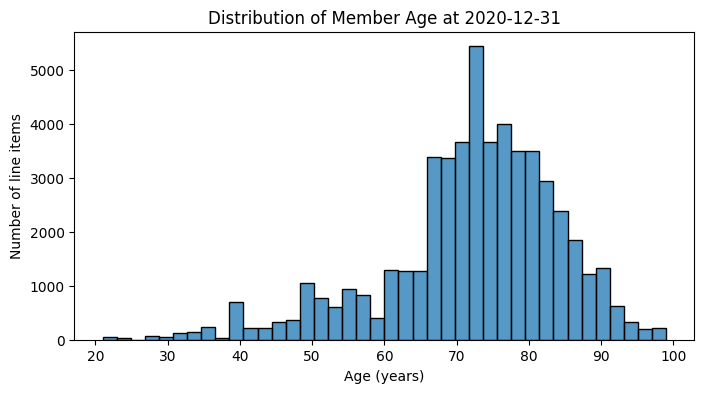

In [11]:
print(f'Mean age:   {df["Age"].mean():.1f}')
print(f'Median age: {df["Age"].median():.1f}')
print(f'Skewness:   {df["Age"].skew():.2f}')
share_65 = (df['Age'] >= 65).mean()
print(f'Share of line items for members aged 65+: {share_65:.1%}')

plt.figure(figsize=(8, 4))
sns.histplot(x=df['Age'], bins=40)
plt.title('Distribution of Member Age at 2020-12-31')
plt.xlabel('Age (years)')
plt.ylabel('Number of line items')
plt.show()

*TODO — your own words: describe the center of the age distribution and the direction of its skew (note the sign of the skewness statistic).*

**C4. Histogram of LengthOfStay** (x-axis capped for readability).

Median stay: 2 days
Mean stay:   3.87 days
Skewness:    7.00
Maximum:     129 days


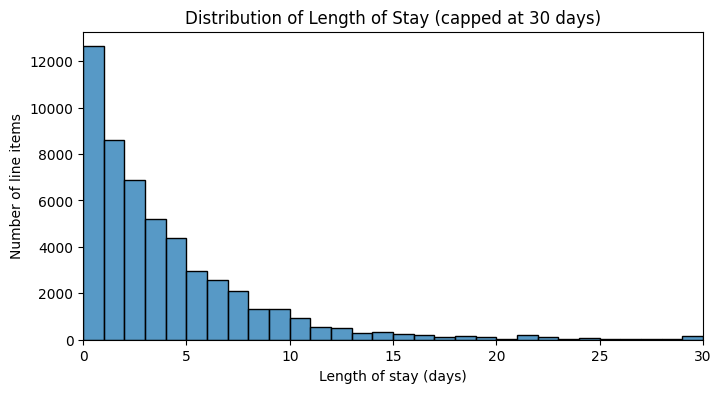

In [12]:
print(f'Median stay: {df["LengthOfStay"].median():.0f} days')
print(f'Mean stay:   {df["LengthOfStay"].mean():.2f} days')
print(f'Skewness:    {df["LengthOfStay"].skew():.2f}')
print(f'Maximum:     {df["LengthOfStay"].max()} days')

plt.figure(figsize=(8, 4))
sns.histplot(x=df['LengthOfStay'], bins=30, binrange=(0, 30))
plt.xlim(0, 30)
plt.title('Distribution of Length of Stay (capped at 30 days)')
plt.xlabel('Length of stay (days)')
plt.ylabel('Number of line items')
plt.show()

*TODO — your own words: describe the shape of the stay distribution and a typical value.*

**C5. Synthesis.**

*TODO — your own words: 2–4 sentences: which variables are right-skewed, which is left-skewed, and why the shape matters when choosing between the mean and the median as a summary statistic.*

## Part D — Discrete Distributions

**D1. Billing-category frequency (RevenueCodeDesc).**

Distinct billing categories: 131
Share of all line items covered by the top ten: 57.0%

RevenueCodeDesc
LABORATORY - CLINICAL DIAGNOSTIC: CHEMISTRY                    5857
EMERGENCY ROOM                                                 4277
LABORATORY - CLINICAL DIAGNOSTIC: HEMATOLOGY                   4037
DRUGS REQUIRE SPECIFIC ID: DRUGS REQUIRING DETAIL CODING       3475
PHARMACY                                                       3109
EKG/ECG                                                        2027
RADIOLOGY - DIAGNOSTIC: CHEST X-RAY                            1862
LABORATORY - CLINICAL DIAGNOSTIC: BACTERIOLOGY/MICROBIOLOGY    1831
LABORATORY - CLINICAL DIAGNOSTIC                               1791
MEDICAL/SURGICAL SUPPLIES: STERILE SUPPLIES                    1697
Name: count, dtype: int64


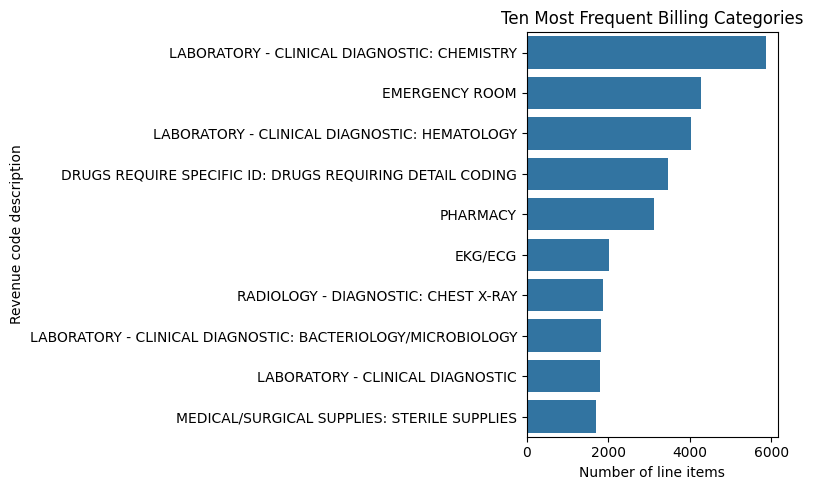

In [13]:
rev_counts = df['RevenueCodeDesc'].value_counts()
print('Distinct billing categories:', df['RevenueCodeDesc'].nunique())
top10 = rev_counts.head(10)
print(f'Share of all line items covered by the top ten: {top10.sum() / len(df):.1%}')
print()
print(top10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top10.values, y=top10.index)
plt.title('Ten Most Frequent Billing Categories')
plt.xlabel('Number of line items')
plt.ylabel('Revenue code description')
plt.tight_layout()
plt.show()

*TODO — your own words: one sentence on what dominates the billing mix (e.g. routine lab / pharmacy items) and what the top-ten share says about concentration.*

**D2. ER visits per member.** Distinct ER claims are counted per member; members with claims in the data but no ER claims are included as zeros.

Members: 1757
Mean ER visits per member:     1.065
Variance of ER visits:         2.186
Fraction with zero ER visits:  33.1%


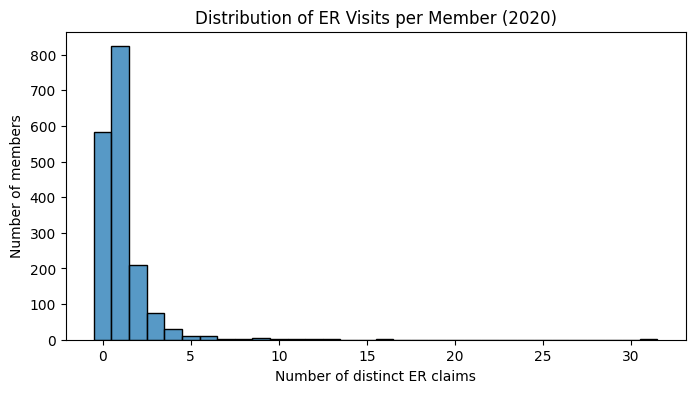

In [14]:
# Distinct ER claims per member, with zero-ER members included via reindex
all_members = df['MemberID'].unique()
er_per_member = (df[df['TypeFlag'] == 'ER']
                 .groupby('MemberID')['MedicalClaim'].nunique()
                 .reindex(all_members, fill_value=0))

print('Members:', len(er_per_member))
print(f'Mean ER visits per member:     {er_per_member.mean():.3f}')
print(f'Variance of ER visits:         {er_per_member.var():.3f}')
print(f'Fraction with zero ER visits:  {(er_per_member == 0).mean():.1%}')

plt.figure(figsize=(8, 4))
sns.histplot(x=er_per_member, bins=range(0, er_per_member.max() + 2), discrete=True)
plt.title('Distribution of ER Visits per Member (2020)')
plt.xlabel('Number of distinct ER claims')
plt.ylabel('Number of members')
plt.show()

*TODO — your own words: one sentence describing the count distribution (most members have 0–1 visits; a small tail has many).*

**D3. Distinct principal diagnoses per member.**

Mean diagnoses per member:  1.772
Variance:                   2.212
Maximum:                    23


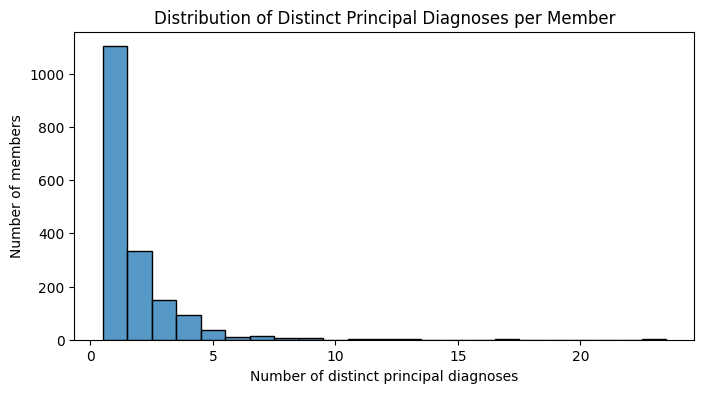

In [15]:
dx_per_member = df.groupby('MemberID')['PrincipalDiagnosis'].nunique()

print(f'Mean diagnoses per member:  {dx_per_member.mean():.3f}')
print(f'Variance:                   {dx_per_member.var():.3f}')
print(f'Maximum:                    {dx_per_member.max()}')

plt.figure(figsize=(8, 4))
sns.histplot(x=dx_per_member, bins=range(1, dx_per_member.max() + 2), discrete=True)
plt.title('Distribution of Distinct Principal Diagnoses per Member')
plt.xlabel('Number of distinct principal diagnoses')
plt.ylabel('Number of members')
plt.show()

*TODO — your own words: one sentence summarizing this distribution.*

**D4. Poisson check.** A Poisson distribution has variance equal to its mean; variance above the mean indicates overdispersion.

In [16]:
for name, s in [('ER visits per member', er_per_member),
                ('Diagnoses per member', dx_per_member)]:
    ratio = s.var() / s.mean()
    verdict = 'overdispersed' if ratio > 1 else 'not overdispersed'
    print(f'{name}: mean = {s.mean():.3f}, variance = {s.var():.3f}, '
          f'variance/mean = {ratio:.2f} → {verdict}')

ER visits per member: mean = 1.065, variance = 2.186, variance/mean = 2.05 → overdispersed
Diagnoses per member: mean = 1.772, variance = 2.212, variance/mean = 1.25 → overdispersed


*TODO — your own words: state whether each count distribution is overdispersed relative to Poisson, and what overdispersion suggests (heterogeneity across members — some are much heavier users than a single-rate Poisson would allow).*

## Part E — Relationships & Concentration

**E1. Correlation matrix and the effect of aggregation grain.**

               TotalExpenses    Age  LengthOfStay
TotalExpenses          1.000  0.027         0.268
Age                    0.027  1.000         0.096
LengthOfStay           0.268  0.096         1.000


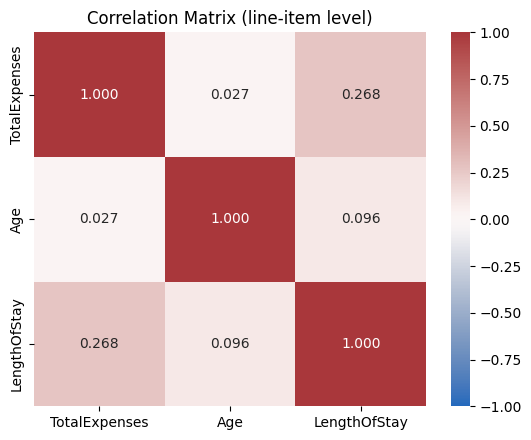

Line-item level corr(cost, stay): 0.268
Claim level corr(cost, stay):     0.786


In [17]:
# Line-item-level correlations among the continuous variables
corr = df[['TotalExpenses', 'Age', 'LengthOfStay']].corr()
print(corr.round(3))

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='vlag', vmin=-1, vmax=1)
plt.title('Correlation Matrix (line-item level)')
plt.tight_layout()
plt.show()

# Recompute the cost-stay relationship at the claim level:
# one row per claim, cost summed, stay length taken once
claims = (df.groupby('MedicalClaim')
            .agg(ClaimTotal=('TotalExpenses', 'sum'),
                 LengthOfStay=('LengthOfStay', 'first')))
claim_corr = claims['ClaimTotal'].corr(claims['LengthOfStay'])
print(f'Line-item level corr(cost, stay): {corr.loc["TotalExpenses", "LengthOfStay"]:.3f}')
print(f'Claim level corr(cost, stay):     {claim_corr:.3f}')

*TODO — your own words: which pairs are most and least related at line-item level, and 2–3 sentences on why the cost–stay correlation jumps so much at the claim level (a long stay generates many cheap line items individually, but a large total once they are summed).*

**E2. Diagnosis → cost, two ways.** The mean-cost ranking is restricted to diagnoses with at least 50 line items so that a handful of records cannot dominate the average — a judgement call; any similar threshold is defensible.

In [18]:
by_dx = (df.groupby('PrincipalDiagnosisDesc')['TotalExpenses']
           .agg(total_spend='sum', mean_cost='mean', line_items='count'))

print('Top ten diagnoses by TOTAL spend:')
print(by_dx.sort_values('total_spend', ascending=False)
           .head(10)[['total_spend', 'line_items']].round(0))
print()
print('Top ten diagnoses by MEAN cost per line item (min 50 line items):')
print(by_dx[by_dx['line_items'] >= 50]
           .sort_values('mean_cost', ascending=False)
           .head(10)[['mean_cost', 'line_items']].round(0))

Top ten diagnoses by TOTAL spend:
                           total_spend  line_items
PrincipalDiagnosisDesc                            
Sepsis unspecified organi   10131632.0        2046
Non-ST elevation (NSTEMI)    6036035.0         992
Atherosclerotic heart dis    5258583.0        1241
Hypertensive heart and ch    3996002.0        1126
Type 2 diabetes mellitus     3492961.0        1011
Cerebral infarction due t    3309356.0         674
Hypertensive heart diseas    3044502.0         972
COVID-19                     2930786.0        1064
Acute kidney failure unsp    2822044.0        1017
Other chest pain             2626890.0        2608

Top ten diagnoses by MEAN cost per line item (min 50 line items):
                           mean_cost  line_items
PrincipalDiagnosisDesc                          
Rheumatic disorders of bo    15022.0          62
Benign neoplasm of pituit    10334.0          61
Nonrheumatic aortic (valv     9876.0         110
Osteomyelitis of vertebra     9280.0      

*TODO — your own words: 2–4 sentences on how the two lists differ — which conditions are high-volume (e.g. sepsis, cardiac disease) versus high-unit-cost (e.g. surgical/orthopaedic conditions).*

**E3. Geographic concentration.**

In [19]:
county = (df.groupby('County')['TotalExpenses']
            .agg(total_spend='sum', mean_cost='mean', line_items='count'))
county['share'] = county['total_spend'] / county['total_spend'].sum()
county = county.sort_values('total_spend', ascending=False)

print('Counties:', len(county))
print(county[['share', 'mean_cost', 'line_items']].round(3).head(10))
print()
top5_share = county['share'].head(5).sum()
print(f'Cumulative share of the top five counties: {top5_share:.1%}')
print(f'Overall mean cost per line item: {df["TotalExpenses"].mean():.0f}')

Counties: 19
          share  mean_cost  line_items
County                                
02af982d  0.485   2961.022       23525
425a37b2  0.166   2523.756        9468
fd218584  0.114   3068.508        5349
89e38653  0.062   2349.649        3767
b021dd12  0.042   2249.052        2679
6f943458  0.041   3209.269        1849
e6708950  0.029   2626.775        1613
7d9b432e  0.016   2756.528         838
ea48569b  0.011   1183.121        1367
6f0b5b6c  0.010   2507.676         555

Cumulative share of the top five counties: 86.8%
Overall mean cost per line item: 2735


*TODO — your own words: 1–2 sentences: is the concentration driven more by volume or by price? (Compare the top counties' mean cost per line item to the overall mean, versus their share of line items.)*

**E4. Age → cost.**

In [20]:
band_order = ['<40', '40–64', '65–79', '80+']
by_band = (df.groupby('AgeBand')['TotalExpenses']
             .agg(mean_cost='mean', total_spend='sum')
             .reindex(band_order))
by_band['spend_share'] = by_band['total_spend'] / by_band['total_spend'].sum()
print(by_band.round(2))
print()
print(f'Correlation between Age and TotalExpenses: '
      f'{df["Age"].corr(df["TotalExpenses"]):.4f}')

         mean_cost  total_spend  spend_share
AgeBand                                     
<40        1324.00    975784.81         0.01
40–64      2020.79  19084387.66         0.13
65–79      2997.55  83274957.99         0.58
80+        2769.45  40436783.64         0.28

Correlation between Age and TotalExpenses: 0.0273


*TODO — your own words: 2–4 sentences reconciling the two findings: which age bands hold most of the total spend, and does age meaningfully predict the cost of an individual line item (look at how small the correlation is)?*

**E5. Closing insight.**

*TODO — your own words: 3–5 sentences pulling Parts C–E together: what concentrates spending in this population (a small high-cost tail of claims, a mostly elderly membership, volume-driven geographic concentration, overdispersed utilisation), and one follow-up question you would investigate.*